# Web Scraping

In [ ]:
#%pip install bs4

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [ ]:
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/154.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

In [52]:
webpage = requests.get("https://www.ambitionbox.com/list-of-companies?sortBy=popular&ratings=4.0&page=1", headers=headers).text

In [53]:
#%pip install parser

In [54]:
import lxml
soup = BeautifulSoup(webpage, "lxml")

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-after"/>
  <meta content="AmbitionBox" data-n-head="ssr" name="ap
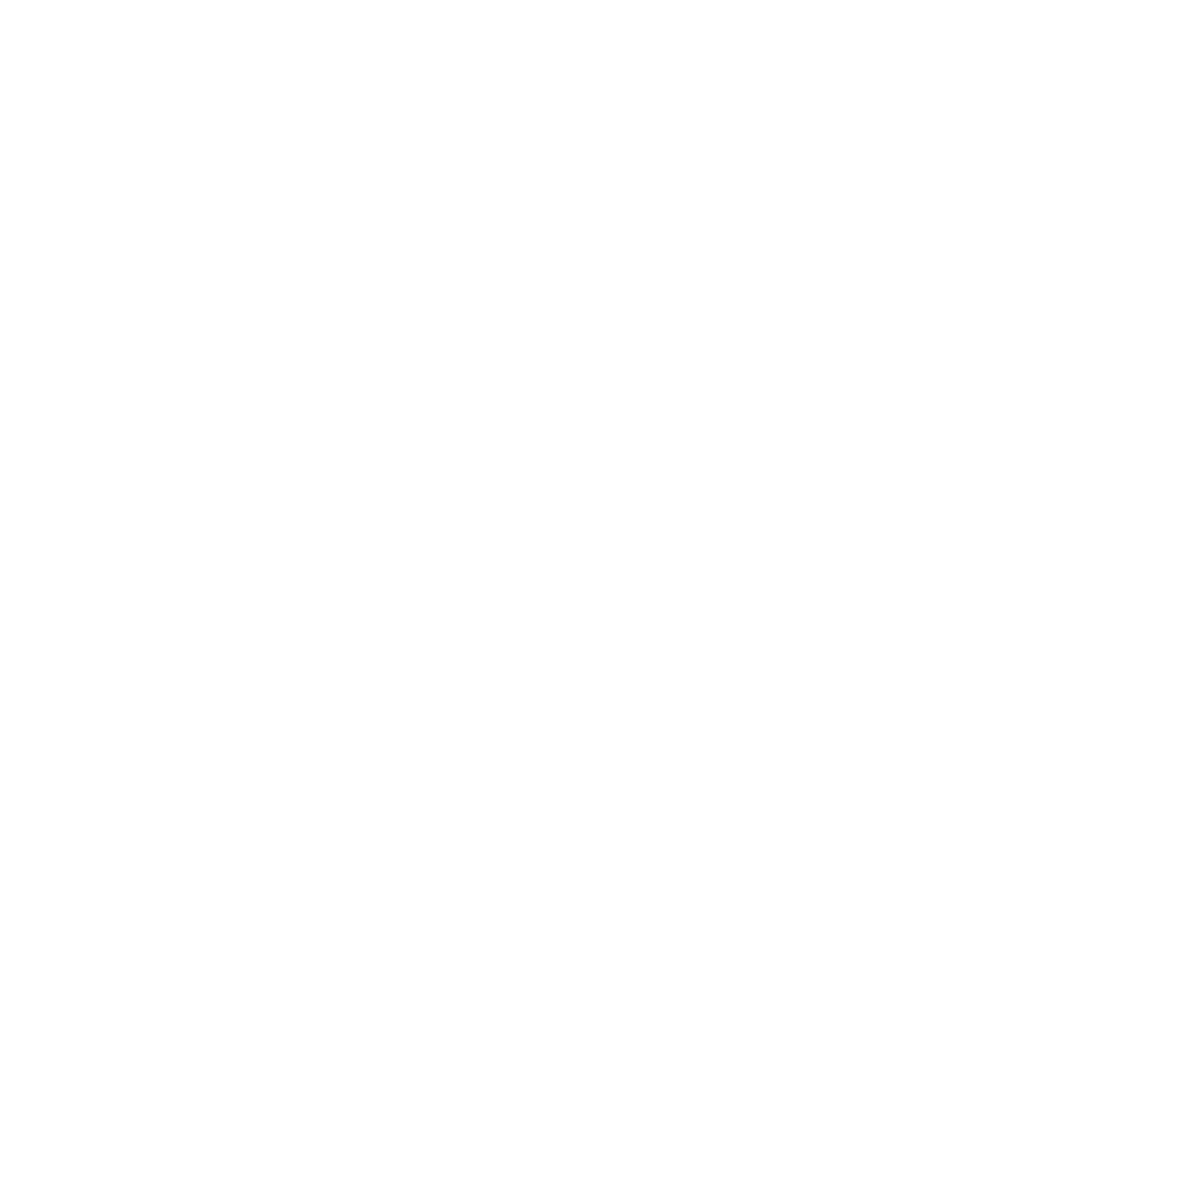

In [55]:
print(soup.prettify())

In [56]:
for i in soup.find_all("h2"):#[0].text
    print(i.text.strip())

ICICI Bank
Jio
iEnergizer
Reliance Industries
IDFC FIRST Bank
Tata Motors
Muthoot FinCorp
Mahindra & Mahindra
Tata Steel
Maruti Suzuki
UltraTech Cement
Equitas Small Finance Bank
Cipla
Dr. Reddy's
Optum Global Solutions
Ujjivan Small Finance Bank
Zydus Lifesciences
Sun Pharmaceutical Industries
Axis Max Life Insurance
Lupin


In [57]:
for i in soup.find_all(class_="rating_text rating_text--md"):
    print(i.text.strip())

4.0
4.3
4.5
4.0
4.0
4.1
4.5
4.0
4.0
4.1
4.1
4.3
4.1
4.0
4.0
4.0
4.0
4.0
4.0
4.1


In [58]:
for i in soup.find_all(class_="companyCardWrapper__companyRatingCount"):
    print(i.text.strip())

(49k)
(35.6k)
(28.6k)
(22.1k)
(16.6k)
(15.4k)
(14.1k)
(13.3k)
(11k)
(10.7k)
(10.6k)
(9.6k)
(9.4k)
(8.9k)
(8.7k)
(8.5k)
(8.3k)
(8.3k)
(8k)
(7.9k)


In [59]:
for i in soup.find_all(class_="companyCardWrapper__interLinking"):
    print(i.text.strip().split("|")[0])

Banking 
Telecom 
BPO 
Oil & Gas 
Banking 
Automobile 
NBFC 
Automobile 
Iron & Steel 
Automobile 
Building Material 
Banking 
Pharma 
Pharma 
IT Services & Consulting 
Banking 
Pharma 
Pharma 
Insurance 
Pharma 


In [60]:
for i in soup.find_all(class_="companyCardWrapper__interLinking"):
    print(i.text.strip().split("|")[1])

 Mumbai +1498 other locations
 Mumbai +2007 other locations
 Noida +58 other locations
 Jamnagar +864 other locations
 Mumbai +774 other locations
 Pune +537 other locations
 Bengaluru +1152 other locations
 Pune +595 other locations
 Jamshedpur +244 other locations
 Gurugram +490 other locations
 Mumbai +574 other locations
 Chennai +494 other locations
 Mumbai +314 other locations
 Hyderabad +226 other locations
 Hyderabad +72 other locations
 Bengaluru +575 other locations
 Ahmedabad +195 other locations
 Vadodara +275 other locations
 New Delhi +542 other locations
 Pune +214 other locations


In [61]:
companies = soup.find_all(class_="companyCardWrapper__primaryInformation")

In [62]:
name = []
rating = []
rating_count = []
company_type = []
company_locations = []

for i in companies:
    name.append(
        i.find("h2")
        .get_text(strip=True))
    
    rating.append(
        i.find(class_="rating_text rating_text--md")
        .get_text(strip=True))
    
    rating_count.append(
        i.find(class_="companyCardWrapper__companyRatingCount")
        .get_text(strip=True))

    location = i.find(
        class_="companyCardWrapper__interLinking"
    ).get_text(" ", strip=True)

    company_type.append(
        location.split("|")[0].strip()
    )

    company_locations.append(
        location.split("|")[1].strip()
    )

In [63]:
d = {"name":name, "rating":rating, "rating_c":rating_count, "company_type":company_type, "company_locations":company_locations}

df = pd.DataFrame(d)

In [64]:
df

,name,rating,rating_c,company_type,company_locations
0,ICICI Bank,4.0,(49k),Banking,Mumbai +1498 other locations
1,Jio,4.3,(35.6k),Telecom,Mumbai +2007 other locations
2,iEnergizer,4.5,(28.6k),BPO,Noida +58 other locations
3,Reliance Industries,4.0,(22.1k),Oil & Gas,Jamnagar +864 other locations
4,IDFC FIRST Bank,4.0,(16.6k),Banking,Mumbai +774 other locations
5,Tata Motors,4.1,(15.4k),Automobile,Pune +537 other locations
6,Muthoot FinCorp,4.5,(14.1k),NBFC,Bengaluru +1152 other locations
7,Mahindra & Mahindra,4.0,(13.3k),Automobile,Pune +595 other locations
8,Tata Steel,4.0,(11k),Iron & Steel,Jamshedpur +244 other locations
9,Maruti Suzuki,4.1,(10.7k),Automobile,Gurugram +490 other locations


In [ ]:
final_df = pd.DataFrame()

for i in range(1,501):

    url = f"https://www.ambitionbox.com/list-of-companies?sortBy=popular&ratings=4.0&page={i}"

    headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/154.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    }
    webpage = requests.get("https://www.ambitionbox.com/list-of-companies?sortBy=popular&ratings=4.0&page=1", headers=headers).text

    soup = BeautifulSoup(webpage, "lxml")

    companies = soup.find_all(class_="companyCardWrapper__primaryInformation")

    name = []
    rating = []
    rating_count = []
    company_type = []
    company_locations = []

    for i in companies:
        name.append(
            i.find("h2")
            .get_text(strip=True))
        
        rating.append(
            i.find(class_="rating_text rating_text--md")
            .get_text(strip=True))
        
        rating_count.append(
            i.find(class_="companyCardWrapper__companyRatingCount")
            .get_text(strip=True))

        location = i.find(
            class_="companyCardWrapper__interLinking"
        ).get_text(" ", strip=True)

        company_type.append(
            location.split("|")[0].strip()
        )

        company_locations.append(
            location.split("|")[1].strip()
        )

    d = {"name":name, "rating":rating, "rating_c":rating_count, "company_type":company_type, "company_locations":company_locations}

    df = pd.DataFrame(d)

    final_df = pd.concat([final_df,df], ignore_index=True)
        

In [ ]:
final_df

,name,rating,rating_c,company_type,company_locations
0,ICICI Bank,4.0,(49k),Banking,Mumbai +1498 other locations
1,Jio,4.3,(35.6k),Telecom,Mumbai +2007 other locations
2,iEnergizer,4.5,(28.6k),BPO,Noida +58 other locations
3,Reliance Industries,4.0,(22.1k),Oil & Gas,Jamnagar +863 other locations
4,IDFC FIRST Bank,4.0,(16.6k),Banking,Mumbai +774 other locations
...,...,...,...,...,...
9995,Ujjivan Small Finance Bank,4.0,(8.5k),Banking,Bengaluru +575 other locations
9996,Zydus Lifesciences,4.0,(8.3k),Pharma,Ahmedabad +195 other locations
9997,Sun Pharmaceutical Industries,4.0,(8.3k),Pharma,Vadodara +275 other locations
9998,Axis Max Life Insurance,4.0,(8k),Insurance,New Delhi +542 other locations


In [ ]:
final_df.to_csv(r"C:\Users\Pranav Wadatkar\Desktop\Python\structured-learning\data\companies.csv", index=False)